In [4]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# Cargar datos
ruta_archivo = 'C:/Users/edamv/retail-sales-analyisis/retail_sales_dataset.csv'
df = pd.read_csv(ruta_archivo)

# Mostrar las primeras 10 filas
print(df.head(10))

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   
5               6  2023-04-25     CUST006  Female   45           Beauty   
6               7  2023-03-13     CUST007    Male   46         Clothing   
7               8  2023-02-22     CUST008    Male   30      Electronics   
8               9  2023-12-13     CUST009    Male   63      Electronics   
9              10  2023-10-07     CUST010  Female   52         Clothing   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30 

In [6]:
# Verificar datos nulos
qsna=df.shape[0]-df.isnull().sum(axis=0)
qna=df.isnull().sum(axis=0)
ppna=round(100*(df.isnull().sum(axis=0)/df.shape[0]),2)
aux= {'datos sin NAs en q': qsna, 'Na en q': qna ,'Na en %': ppna}
na=pd.DataFrame(data=aux)
na.sort_values(by='Na en %',ascending=False)

,datos sin NAs en q,Na en q,Na en %
Transaction ID,1000,0,0.0
Date,1000,0,0.0
Customer ID,1000,0,0.0
Gender,1000,0,0.0
Age,1000,0,0.0
Product Category,1000,0,0.0
Quantity,1000,0,0.0
Price per Unit,1000,0,0.0
Total Amount,1000,0,0.0


In [7]:
#Ver duplicados

# Detectar filas duplicadas
duplicados = df[df.duplicated()]

# Mostrar cantidad de filas duplicadas
cantidad_duplicados = df.duplicated().sum()
print(f"Cantidad de filas duplicadas: {cantidad_duplicados}")

Cantidad de filas duplicadas: 0


In [8]:
# Exploración inicial
print(df.head(10))
print(df.info())
print(df.describe())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   
5               6  2023-04-25     CUST006  Female   45           Beauty   
6               7  2023-03-13     CUST007    Male   46         Clothing   
7               8  2023-02-22     CUST008    Male   30      Electronics   
8               9  2023-12-13     CUST009    Male   63      Electronics   
9              10  2023-10-07     CUST010  Female   52         Clothing   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30 

In [9]:
# Convertir la columna 'fecha' a formato datetime
df['Date'] = pd.to_datetime(df['Date'])
print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


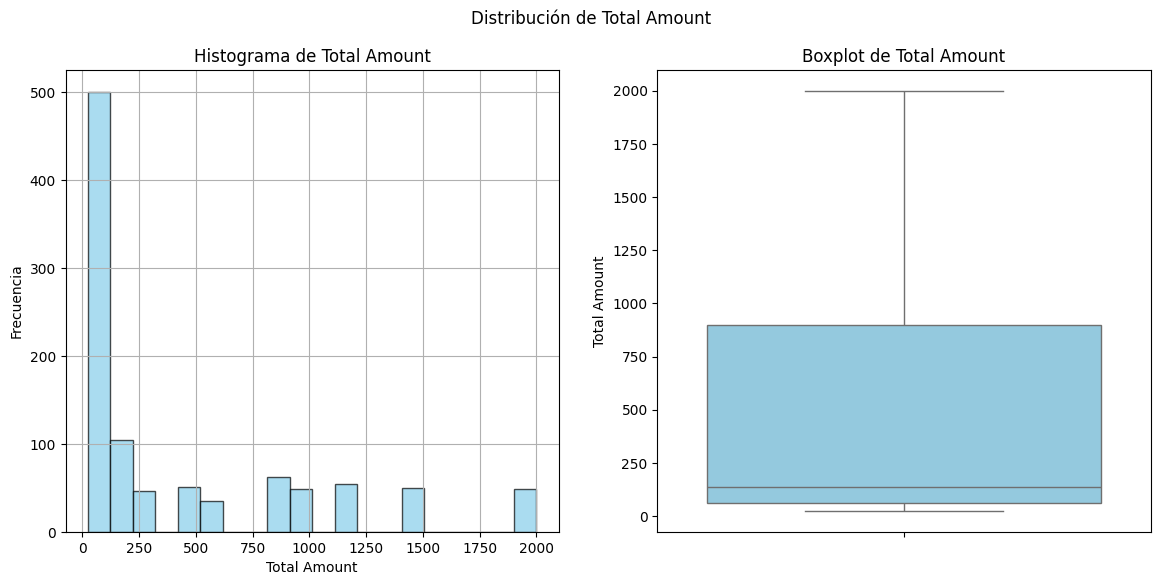

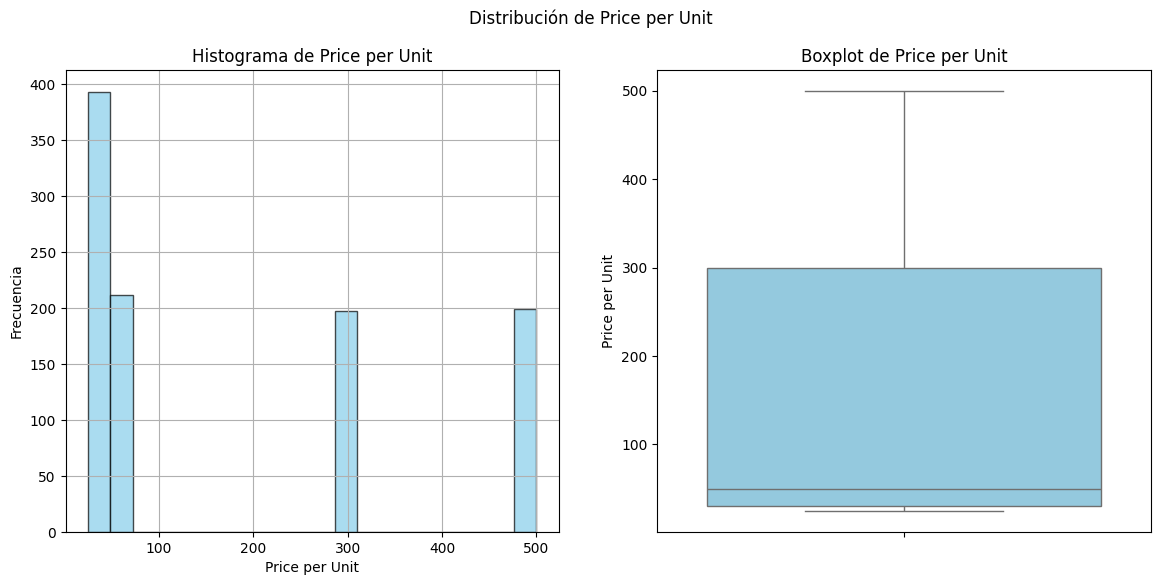

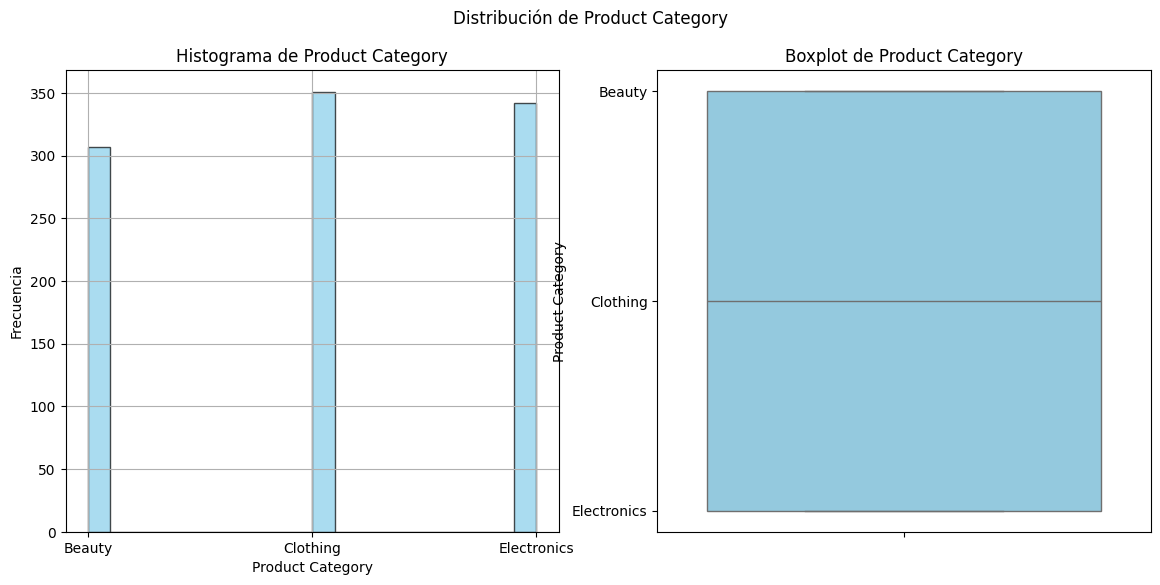

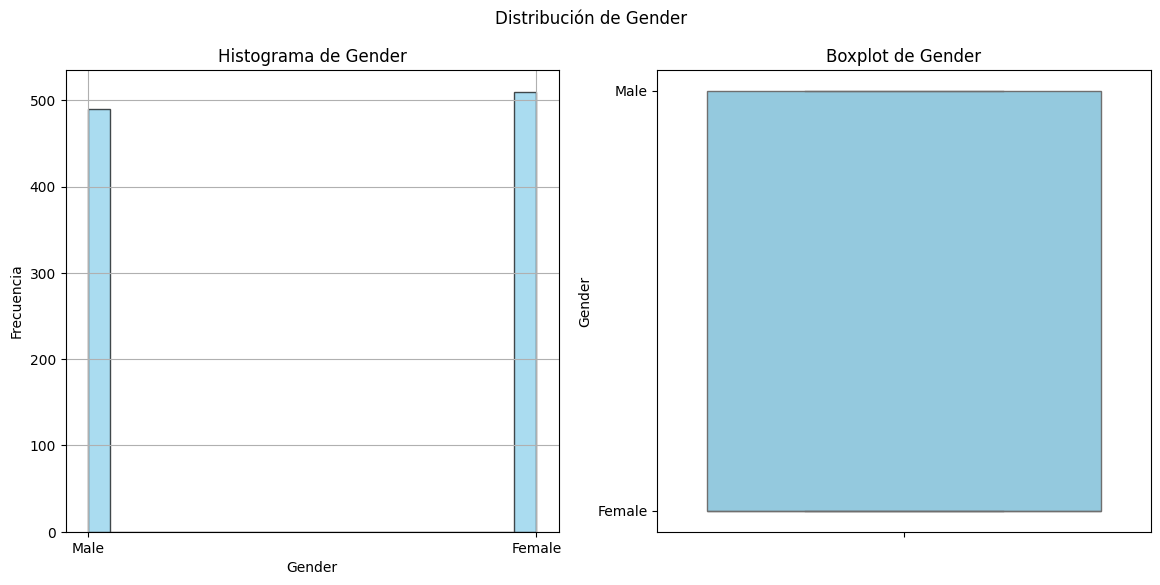

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear histogramas y boxplots
variables = ['Total Amount', 'Price per Unit', 'Product Category', 'Gender']
for var in variables:
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    # Histograma
    ax[0].hist(df[var], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    ax[0].set_title(f'Histograma de {var}')
    ax[0].set_xlabel(var)
    ax[0].set_ylabel('Frecuencia')
    ax[0].grid(True)
    
    # Boxplot
    sns.boxplot(y=df[var], color='skyblue', ax=ax[1])
    ax[1].set_title(f'Boxplot de {var}')
    ax[1].set_ylabel(var)
    
    plt.suptitle(f'Distribución de {var}')
    plt.show()


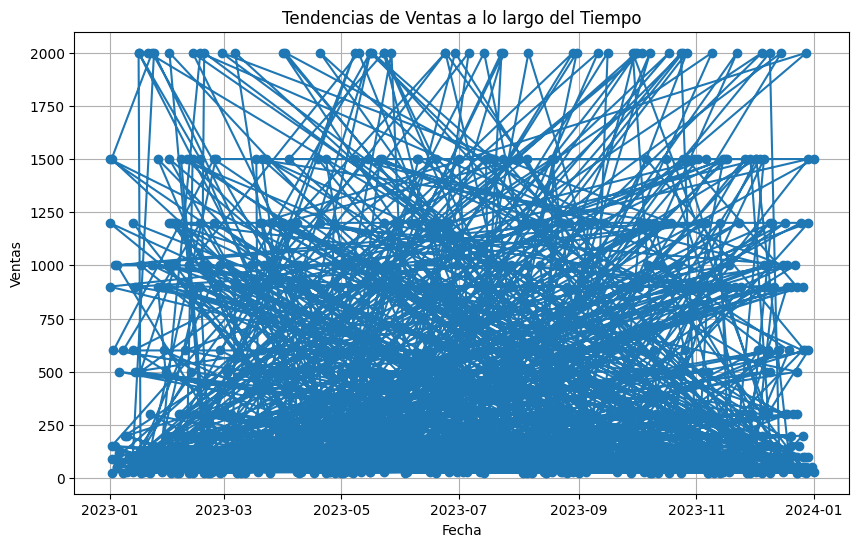

In [13]:
#Gráficos de Líneas para Tendencias de Ventas:
# Convertir la columna de fecha a formato datetime si aún no lo está
df['Date'] = pd.to_datetime(df['Date'])

# Gráfico de líneas para mostrar tendencias de ventas a lo largo del tiempo
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['Total Amount'], marker='o', linestyle='-')
plt.title("Tendencias de Ventas a lo largo del Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()


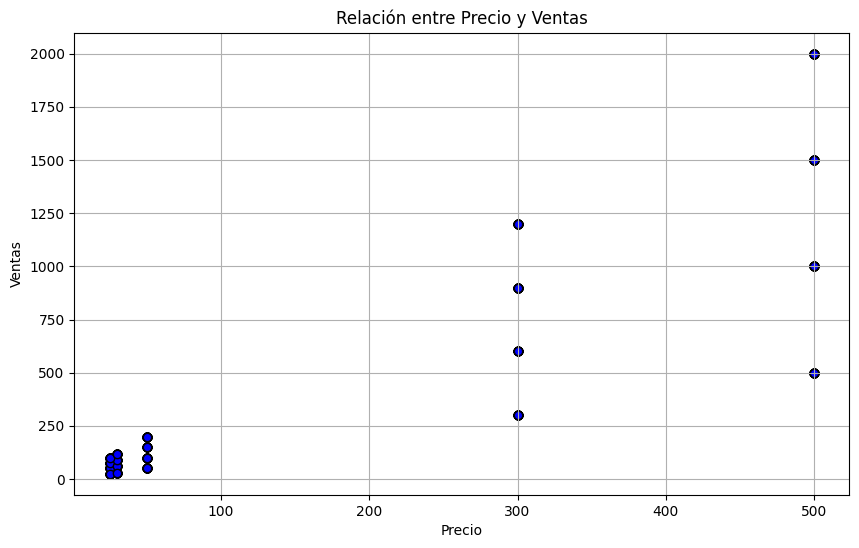

In [15]:
#Gráficos de Dispersión para Analizar Relaciones entre Variables:
# Gráfico de dispersión entre Precio y Ventas
plt.figure(figsize=(10, 6))
plt.scatter(df['Price per Unit'], df['Total Amount'], color='blue', edgecolor='black')
plt.title("Relación entre Precio y Ventas")
plt.xlabel("Precio")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()
